In [ ]:
import pandas as pd
from google.colab import files
import io

# Run this to get the upload button
print("Please upload your 'insurance.csv' file:")
uploaded = files.upload()

# Get the first filename uploaded dynamically
filename = list(uploaded.keys())[0]

# Load the data
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Clean column names (removes any accidental spaces)
df.columns = df.columns.str.strip()

print(f"Data loaded successfully from {filename}!")
print(df.head())

Please upload your 'insurance.csv' file:


Saving insurance.csv to insurance (4).csv
Data loaded successfully from insurance (4).csv!
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [ ]:
# Convert categorical variables into numbers
df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# Separate features (X) and target (y)
X = df.drop('charges', axis=1)
y = df['charges']

print("Preprocessing complete!")
print("New feature columns:", X.columns.tolist())

Preprocessing complete!
New feature columns: ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


R-squared Score: 0.7836


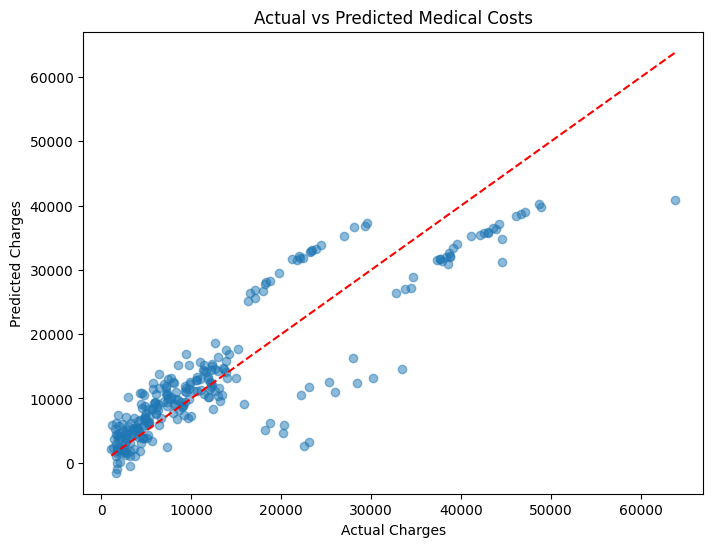

In [ ]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")

# Plot results
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Medical Costs")
plt.show()